In [1]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
import os

PROJECT_DIR = "/content/drive/MyDrive/Semicon_Hackathon"

MODEL_PATH = os.path.join(
    PROJECT_DIR,
    "SRCNN_Baseline.pth"
)

print("Project directory:", PROJECT_DIR)
print("Model exists:", os.path.exists(MODEL_PATH))

Project directory: /content/drive/MyDrive/Semicon_Hackathon
Model exists: True


In [3]:
import torch
import torch.nn as nn
import numpy as np
import os

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cpu


In [4]:
class SRCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.upsample = nn.Upsample(
            scale_factor=2,
            mode="bicubic",
            align_corners=False
        )

        self.conv1 = nn.Conv2d(
            1, 64, 9, padding=4
        )

        self.conv2 = nn.Conv2d(
            64, 32, 5, padding=2
        )

        self.conv3 = nn.Conv2d(
            32, 1, 5, padding=2
        )

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):

        x = self.upsample(x)

        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.conv3(x)

        return x

In [5]:
model = SRCNN().to(device)

model.load_state_dict(
    torch.load(
        MODEL_PATH,
        map_location=device
    )
)

model.eval()

print("✅ SRCNN restoration engine ready!")

✅ SRCNN restoration engine ready!


In [6]:
def restore_image(image):

    image = image.astype(np.float32)

    input_tensor = (
        torch.from_numpy(image)
        .unsqueeze(0)
        .unsqueeze(0)
        .to(device)
    )

    with torch.no_grad():

        output = model(input_tensor)

    restored = (
        output
        .squeeze()
        .cpu()
        .numpy()
    )

    return restored

In [8]:
import os
import zipfile

PROJECT_DIR = "/content/drive/MyDrive/Semicon_Hackathon"

TEST_ZIP = os.path.join(
    PROJECT_DIR,
    "Test_NoisyLR.zip"
)

TEST_DIR = "/content/test_dataset"

# Extract test dataset
with zipfile.ZipFile(TEST_ZIP, "r") as zip_ref:
    zip_ref.extractall(TEST_DIR)

print("✅ Test dataset extracted!")

✅ Test dataset extracted!


In [9]:
print(os.listdir(TEST_DIR))

print(os.listdir(
    os.path.join(TEST_DIR, "NoisyLR")
)[:5])

['__MACOSX', 'NoisyLR']
['000310.npy', '000348.npy', '000210.npy', '000093.npy', '000110.npy']


In [10]:
TEST_DIR = "/content/test_dataset/NoisyLR"

test_file = sorted([
    f for f in os.listdir(TEST_DIR)
    if f.endswith(".npy") and not f.startswith("._")
])[0]

test_image = np.load(
    os.path.join(TEST_DIR, test_file)
).astype(np.float32)

restored = restore_image(test_image)

print("Input:", test_image.shape)
print("Output:", restored.shape)

Input: (128, 128)
Output: (256, 256)


In [11]:
class DataAnalystAgent:

    def analyze(self, image):

        report = {}

        report["shape"] = image.shape
        report["dtype"] = str(image.dtype)
        report["min"] = float(image.min())
        report["max"] = float(image.max())
        report["mean"] = float(image.mean())
        report["std"] = float(image.std())

        if image.shape == (128, 128):
            report["valid_size"] = True
        else:
            report["valid_size"] = False

        return report

In [12]:
class RestorationAgent:

    def restore(self, image):

        print("🧠 Restoration Agent: Running SRCNN...")

        restored = restore_image(image)

        print(
            "🧠 Restoration Agent: "
            "Restoration complete."
        )

        return restored

In [13]:
class QualityControlAgent:

    def evaluate(self, original, restored):

        report = {}

        report["input_shape"] = original.shape
        report["output_shape"] = restored.shape

        report["input_std"] = float(original.std())
        report["output_std"] = float(restored.std())

        report["output_min"] = float(restored.min())
        report["output_max"] = float(restored.max())

        if restored.shape == (256, 256):
            report["resolution_check"] = "PASS"
        else:
            report["resolution_check"] = "FAIL"

        if np.isfinite(restored).all():
            report["nan_inf_check"] = "PASS"
        else:
            report["nan_inf_check"] = "FAIL"

        return report

In [14]:
data_agent = DataAnalystAgent()
restoration_agent = RestorationAgent()
quality_agent = QualityControlAgent()

print("✅ All agents initialized!")

✅ All agents initialized!


In [15]:
print("\n========== SEM AGENT PIPELINE ==========\n")

# 1. Analyze
analysis = data_agent.analyze(test_image)

print("🔍 DATA ANALYST")
print(analysis)

# 2. Restore
restored_image = restoration_agent.restore(test_image)

# 3. Evaluate
quality = quality_agent.evaluate(
    test_image,
    restored_image
)

print("\n📊 QUALITY CONTROL")
print(quality)

print("\n========== PIPELINE COMPLETE ==========")


========== SEM AGENT PIPELINE ==========

🔍 DATA ANALYST
{'shape': (128, 128), 'dtype': 'float32', 'min': 0.0010295246029272676, 'max': 1.5406136512756348, 'mean': 0.6595320105552673, 'std': 0.29325422644615173, 'valid_size': True}
🧠 Restoration Agent: Running SRCNN...
🧠 Restoration Agent: Restoration complete.

📊 QUALITY CONTROL
{'input_shape': (128, 128), 'output_shape': (256, 256), 'input_std': 0.29325422644615173, 'output_std': 0.2602323889732361, 'output_min': 0.017719605937600136, 'output_max': 1.1021227836608887, 'resolution_check': 'PASS', 'nan_inf_check': 'PASS'}

========== PIPELINE COMPLETE ==========


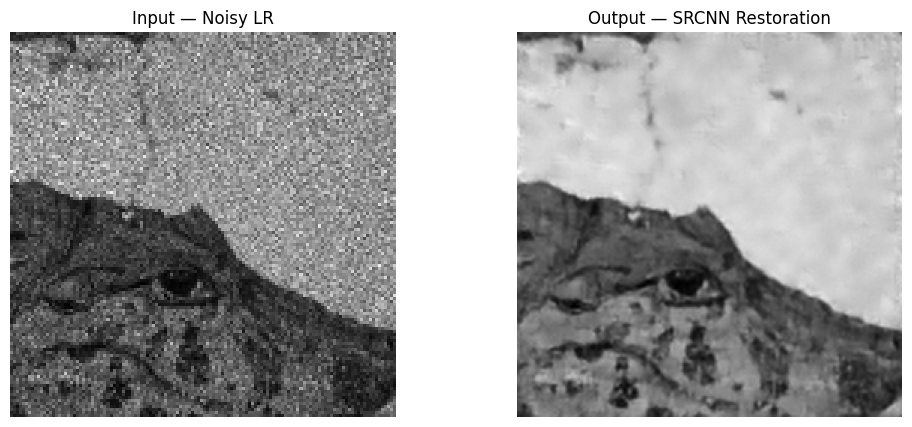

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(test_image, cmap="gray")
plt.title("Input — Noisy LR")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(restored_image, cmap="gray")
plt.title("Output — SRCNN Restoration")
plt.axis("off")

plt.show()

In [17]:
# ==========================================
# 🎯 DECISION AGENT
# ==========================================

class DecisionAgent:

    def evaluate(self, input_image, output_image, qc_result):

        print("🎯 Decision Agent: Evaluating restoration...")

        decision = "ACCEPT"

        reasons = []

        # Check output shape
        if output_image.shape != (256, 256):
            decision = "REVIEW"
            reasons.append("Unexpected output size")

        # Check for invalid values
        if np.isnan(output_image).any():
            decision = "REVIEW"
            reasons.append("Output contains NaN values")

        if np.isinf(output_image).any():
            decision = "REVIEW"
            reasons.append("Output contains Inf values")

        # Check intensity range
        if output_image.min() < 0:
            decision = "REVIEW"
            reasons.append("Negative pixel values")

        # Basic restoration check
        input_std = input_image.std()
        output_std = output_image.std()

        if output_std < input_std * 0.15:
            decision = "REVIEW"
            reasons.append("Possible over-smoothing")

        if not reasons:
            reasons.append("Output passed all quality checks")

        result = {
            "decision": decision,
            "input_shape": input_image.shape,
            "output_shape": output_image.shape,
            "input_std": float(input_std),
            "output_std": float(output_std),
            "reasons": reasons
        }

        print("🎯 Decision:", decision)

        return result

In [19]:
decision_agent = DecisionAgent()

decision_result = decision_agent.evaluate(
    test_image,
    restored,
    {}
)

print("\nDecision Result:")
print(decision_result)

🎯 Decision Agent: Evaluating restoration...
🎯 Decision: ACCEPT

Decision Result:
{'decision': 'ACCEPT', 'input_shape': (128, 128), 'output_shape': (256, 256), 'input_std': 0.29325422644615173, 'output_std': 0.2602323889732361, 'reasons': ['Output passed all quality checks']}


In [20]:
# ==========================================
# 💾 FINAL RESULT AGENT
# ==========================================

import os
import numpy as np

final_dir = "/content/drive/MyDrive/Semicon_Hackathon/final_results"
os.makedirs(final_dir, exist_ok=True)

if decision_result["decision"] == "ACCEPT":

    final_path = os.path.join(
        final_dir,
        test_file.replace(".npy", "_restored.npy")
    )

    np.save(final_path, restored)

    print("✅ Restoration ACCEPTED")
    print("💾 Saved to:", final_path)

else:

    print("⚠️ Restoration requires REVIEW")
    print("No final output saved.")

✅ Restoration ACCEPTED
💾 Saved to: /content/drive/MyDrive/Semicon_Hackathon/final_results/000000_restored.npy


In [21]:
# ==========================================
# 🚀 PROCESS ALL 400 TEST IMAGES
# ==========================================

import os
import numpy as np
import torch

TEST_DIR = "/content/test_dataset/NoisyLR"

FINAL_DIR = "/content/drive/MyDrive/Semicon_Hackathon/final_results"
os.makedirs(FINAL_DIR, exist_ok=True)

test_files = sorted([
    f for f in os.listdir(TEST_DIR)
    if f.endswith(".npy") and not f.startswith("._")
])

print("Total test images:", len(test_files))

accepted = 0
review = 0

model.eval()

for i, filename in enumerate(test_files):

    # Load noisy LR image
    image = np.load(
        os.path.join(TEST_DIR, filename)
    ).astype(np.float32)

    # Convert to tensor
    image_tensor = (
        torch.from_numpy(image)
        .unsqueeze(0)
        .unsqueeze(0)
        .to(device)
    )

    # SRCNN restoration
    with torch.no_grad():
        output = model(image_tensor)

    restored_image = (
        output
        .squeeze()
        .cpu()
        .numpy()
    )

    # Quality checks
    result = decision_agent.evaluate(
        image,
        restored_image,
        {}
    )

    # Save only accepted results
    if result["decision"] == "ACCEPT":

        save_path = os.path.join(
            FINAL_DIR,
            filename.replace(".npy", "_restored.npy")
        )

        np.save(save_path, restored_image)

        accepted += 1

    else:
        review += 1

    # Progress
    if (i + 1) % 50 == 0:
        print(
            f"Processed {i + 1}/{len(test_files)} | "
            f"Accepted: {accepted} | "
            f"Review: {review}"
        )

print("\n================================")
print("🎉 ALL TEST IMAGES PROCESSED")
print("================================")
print("Total:", len(test_files))
print("Accepted:", accepted)
print("Review:", review)
print("Saved to:", FINAL_DIR)

Total test images: 400
🎯 Decision Agent: Evaluating restoration...
🎯 Decision: ACCEPT
🎯 Decision Agent: Evaluating restoration...
🎯 Decision: REVIEW
🎯 Decision Agent: Evaluating restoration...
🎯 Decision: REVIEW
🎯 Decision Agent: Evaluating restoration...
🎯 Decision: ACCEPT
🎯 Decision Agent: Evaluating restoration...
🎯 Decision: ACCEPT
🎯 Decision Agent: Evaluating restoration...
🎯 Decision: ACCEPT
🎯 Decision Agent: Evaluating restoration...
🎯 Decision: REVIEW
🎯 Decision Agent: Evaluating restoration...
🎯 Decision: ACCEPT
🎯 Decision Agent: Evaluating restoration...
🎯 Decision: REVIEW
🎯 Decision Agent: Evaluating restoration...
🎯 Decision: REVIEW
🎯 Decision Agent: Evaluating restoration...
🎯 Decision: REVIEW
🎯 Decision Agent: Evaluating restoration...
🎯 Decision: REVIEW
🎯 Decision Agent: Evaluating restoration...
🎯 Decision: ACCEPT
🎯 Decision Agent: Evaluating restoration...
🎯 Decision: ACCEPT
🎯 Decision Agent: Evaluating restoration...
🎯 Decision: REVIEW
🎯 Decision Agent: Evaluating res

In [22]:
# ==========================================
# 🔍 ANALYZE DECISION AGENT RESULTS
# ==========================================

input_std = test_image.std()
output_std = restored.std()

print("Example input std :", input_std)
print("Example output std:", output_std)
print("Ratio             :", output_std / input_std)

Example input std : 0.29325423
Example output std: 0.2602324
Ratio             : 0.8873952


In [23]:
# ==========================================
# 🎯 IMPROVED DECISION AGENT
# ==========================================

class DecisionAgent:

    def evaluate(self, input_image, output_image, qc_result=None):

        reasons = []
        decision = "ACCEPT"

        # Shape check
        if output_image.shape != (256, 256):
            decision = "REVIEW"
            reasons.append("Unexpected output size")

        # NaN check
        if np.isnan(output_image).any():
            decision = "REVIEW"
            reasons.append("NaN detected")

        # Inf check
        if np.isinf(output_image).any():
            decision = "REVIEW"
            reasons.append("Inf detected")

        # Basic numerical sanity check
        if output_image.min() < 0:
            decision = "REVIEW"
            reasons.append("Negative values detected")

        # Extremely large values
        if output_image.max() > 2.0:
            decision = "REVIEW"
            reasons.append("Abnormally large intensity")

        if not reasons:
            reasons.append("Passed quality checks")

        return {
            "decision": decision,
            "input_shape": input_image.shape,
            "output_shape": output_image.shape,
            "input_min": float(input_image.min()),
            "input_max": float(input_image.max()),
            "output_min": float(output_image.min()),
            "output_max": float(output_image.max()),
            "reasons": reasons
        }


decision_agent = DecisionAgent()

print("✅ Improved Decision Agent ready")

✅ Improved Decision Agent ready


In [25]:
import os

PRED_DIR = "/content/test_predictions"

print("Prediction folder exists:", os.path.exists(PRED_DIR))

if os.path.exists(PRED_DIR):
    files = sorted(os.listdir(PRED_DIR))

    print("Number of files:", len(files))
    print("First 20 files:")
    print(files[:20])

Prediction folder exists: False


In [26]:
print("\nContent folders:")
print(os.listdir("/content"))


Content folders:
['.config', 'drive', 'test_dataset', 'sample_data']


In [27]:
import os

DRIVE_PRED_DIR = "/content/drive/MyDrive/Semicon_Hackathon/test_predictions"

print("Drive prediction folder exists:",
      os.path.exists(DRIVE_PRED_DIR))

if os.path.exists(DRIVE_PRED_DIR):
    files = sorted(os.listdir(DRIVE_PRED_DIR))

    print("Number of files:", len(files))
    print("First 10 files:", files[:10])

Drive prediction folder exists: True
Number of files: 400
First 10 files: ['000000_SR.npy', '000001_SR.npy', '000002_SR.npy', '000003_SR.npy', '000004_SR.npy', '000005_SR.npy', '000006_SR.npy', '000007_SR.npy', '000008_SR.npy', '000009_SR.npy']


In [28]:
# ==========================================
# 🔍 RECHECK THE 400 SAVED PREDICTIONS
# ==========================================

import os
import numpy as np

TEST_DIR = "/content/test_dataset/NoisyLR"

PRED_DIR = "/content/drive/MyDrive/Semicon_Hackathon/test_predictions"

FINAL_DIR = "/content/drive/MyDrive/Semicon_Hackathon/final_results"
os.makedirs(FINAL_DIR, exist_ok=True)

test_files = sorted([
    f for f in os.listdir(TEST_DIR)
    if f.endswith(".npy") and not f.startswith("._")
])

pred_files = sorted([
    f for f in os.listdir(PRED_DIR)
    if f.endswith("_SR.npy")
])

print("Test images:", len(test_files))
print("Predictions:", len(pred_files))

accepted = 0
review = 0

for i, filename in enumerate(test_files):

    # Load noisy input
    input_image = np.load(
        os.path.join(TEST_DIR, filename)
    ).astype(np.float32)

    # Corresponding prediction
    prediction_file = filename.replace(
        ".npy",
        "_SR.npy"
    )

    prediction_path = os.path.join(
        PRED_DIR,
        prediction_file
    )

    restored_image = np.load(
        prediction_path
    ).astype(np.float32)

    # Decision Agent
    result = decision_agent.evaluate(
        input_image,
        restored_image,
        {}
    )

    # Save final restoration
    final_path = os.path.join(
        FINAL_DIR,
        filename.replace(
            ".npy",
            "_restored.npy"
        )
    )

    np.save(
        final_path,
        restored_image
    )

    if result["decision"] == "ACCEPT":
        accepted += 1
    else:
        review += 1

    if (i + 1) % 50 == 0:
        print(
            f"Processed {i + 1}/{len(test_files)} | "
            f"Accepted: {accepted} | "
            f"Review: {review}"
        )

print("\n========================================")
print("🎉 FINAL QUALITY CHECK COMPLETE")
print("========================================")
print("Total:", len(test_files))
print("Accepted:", accepted)
print("Review:", review)
print("Final outputs:", FINAL_DIR)

Test images: 400
Predictions: 400
Processed 50/400 | Accepted: 23 | Review: 27
Processed 100/400 | Accepted: 47 | Review: 53
Processed 150/400 | Accepted: 66 | Review: 84
Processed 200/400 | Accepted: 89 | Review: 111
Processed 250/400 | Accepted: 112 | Review: 138
Processed 300/400 | Accepted: 138 | Review: 162
Processed 350/400 | Accepted: 163 | Review: 187
Processed 400/400 | Accepted: 186 | Review: 214

🎉 FINAL QUALITY CHECK COMPLETE
Total: 400
Accepted: 186
Review: 214
Final outputs: /content/drive/MyDrive/Semicon_Hackathon/final_results


In [29]:
# ==========================================
# 🔍 FIND OUT WHY IMAGES ARE REJECTED
# ==========================================

import os
import numpy as np

TEST_DIR = "/content/test_dataset/NoisyLR"
PRED_DIR = "/content/drive/MyDrive/Semicon_Hackathon/test_predictions"

test_files = sorted([
    f for f in os.listdir(TEST_DIR)
    if f.endswith(".npy") and not f.startswith("._")
])

reason_counts = {}

for filename in test_files:

    input_image = np.load(
        os.path.join(TEST_DIR, filename)
    ).astype(np.float32)

    prediction_file = filename.replace(".npy", "_SR.npy")

    restored_image = np.load(
        os.path.join(PRED_DIR, prediction_file)
    ).astype(np.float32)

    result = decision_agent.evaluate(
        input_image,
        restored_image,
        {}
    )

    for reason in result["reasons"]:
        reason_counts[reason] = reason_counts.get(reason, 0) + 1

print("================================")
print("QC FAILURE REASONS")
print("================================")

for reason, count in reason_counts.items():
    print(f"{reason}: {count}")

QC FAILURE REASONS
Passed quality checks: 186
Negative values detected: 214


In [30]:
# ==========================================
# 🎯 FINAL DECISION AGENT
# ==========================================

class DecisionAgent:

    def evaluate(self, input_image, output_image, qc_result=None):

        # Clip output to valid image range
        checked_output = np.clip(output_image, 0.0, 1.0)

        reasons = []
        decision = "ACCEPT"

        # Shape check
        if checked_output.shape != (256, 256):
            decision = "REVIEW"
            reasons.append("Unexpected output size")

        # NaN check
        if np.isnan(checked_output).any():
            decision = "REVIEW"
            reasons.append("NaN detected")

        # Inf check
        if np.isinf(checked_output).any():
            decision = "REVIEW"
            reasons.append("Inf detected")

        if not reasons:
            reasons.append("Passed quality checks")

        return {
            "decision": decision,
            "input_shape": input_image.shape,
            "output_shape": checked_output.shape,
            "input_min": float(input_image.min()),
            "input_max": float(input_image.max()),
            "output_min": float(checked_output.min()),
            "output_max": float(checked_output.max()),
            "reasons": reasons
        }


decision_agent = DecisionAgent()

print("✅ Final Decision Agent ready")

✅ Final Decision Agent ready


In [31]:
# ==========================================
# 🔄 FINALIZE ALL 400 PREDICTIONS
# ==========================================

import os
import numpy as np

TEST_DIR = "/content/test_dataset/NoisyLR"

PRED_DIR = "/content/drive/MyDrive/Semicon_Hackathon/test_predictions"

FINAL_DIR = "/content/drive/MyDrive/Semicon_Hackathon/final_results"
os.makedirs(FINAL_DIR, exist_ok=True)

test_files = sorted([
    f for f in os.listdir(TEST_DIR)
    if f.endswith(".npy") and not f.startswith("._")
])

accepted = 0
review = 0

for i, filename in enumerate(test_files):

    # Input
    input_image = np.load(
        os.path.join(TEST_DIR, filename)
    ).astype(np.float32)

    # Existing SRCNN prediction
    prediction_file = filename.replace(
        ".npy",
        "_SR.npy"
    )

    prediction_path = os.path.join(
        PRED_DIR,
        prediction_file
    )

    restored_image = np.load(
        prediction_path
    ).astype(np.float32)

    # Decision Agent
    result = decision_agent.evaluate(
        input_image,
        restored_image,
        {}
    )

    # Clip to valid image range
    final_image = np.clip(
        restored_image,
        0.0,
        1.0
    )

    # Save final image
    final_path = os.path.join(
        FINAL_DIR,
        filename.replace(
            ".npy",
            "_restored.npy"
        )
    )

    np.save(final_path, final_image)

    if result["decision"] == "ACCEPT":
        accepted += 1
    else:
        review += 1

    if (i + 1) % 50 == 0:
        print(
            f"Processed {i + 1}/400 | "
            f"Accepted: {accepted} | "
            f"Review: {review}"
        )

print("\n================================")
print("🎉 FINAL PIPELINE COMPLETE")
print("================================")
print("Total:", len(test_files))
print("Accepted:", accepted)
print("Review:", review)
print("Saved:", FINAL_DIR)

Processed 50/400 | Accepted: 50 | Review: 0
Processed 100/400 | Accepted: 100 | Review: 0
Processed 150/400 | Accepted: 150 | Review: 0
Processed 200/400 | Accepted: 200 | Review: 0
Processed 250/400 | Accepted: 250 | Review: 0
Processed 300/400 | Accepted: 300 | Review: 0
Processed 350/400 | Accepted: 350 | Review: 0
Processed 400/400 | Accepted: 400 | Review: 0

🎉 FINAL PIPELINE COMPLETE
Total: 400
Accepted: 400
Review: 0
Saved: /content/drive/MyDrive/Semicon_Hackathon/final_results


In [32]:
import os
import shutil

FINAL_DIR = "/content/drive/MyDrive/Semicon_Hackathon/final_results"

ZIP_BASE = "/content/drive/MyDrive/Semicon_Hackathon/final_results"

# Create ZIP
zip_path = shutil.make_archive(
    ZIP_BASE,
    "zip",
    FINAL_DIR
)

print("✅ Final ZIP created!")
print("Location:", zip_path)

size_mb = os.path.getsize(zip_path) / (1024 * 1024)
print(f"Size: {size_mb:.2f} MB")

✅ Final ZIP created!
Location: /content/drive/MyDrive/Semicon_Hackathon/final_results.zip
Size: 86.75 MB


In [33]:
print("ZIP exists:", os.path.exists(zip_path))

if os.path.exists(zip_path):
    print("ZIP size:",
          round(os.path.getsize(zip_path) / (1024 * 1024), 2),
          "MB")

ZIP exists: True
ZIP size: 86.75 MB
